# EDA Techniques in Python Course

Importing the necessary Libraries

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sn

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("parulpandey/2020-it-salary-survey-for-eu-region")

print("Path to dataset files:", path)

100%|██████████| 85.0k/85.0k [00:00<00:00, 383kB/s]

Extracting files...
Path to dataset files: C:\Users\tahaa\.cache\kagglehub\datasets\parulpandey\2020-it-salary-survey-for-eu-region\versions\2


In [2]:
df = pd.read_csv(r'C:\Users\tahaa\Documents\GitHub\ML-Training-Projects\00_EDA\Data\IT Salary Survey EU 2020.csv')
df.head(10)

,Timestamp,Age,Gender,City,Position,Total years of experience,Years of experience in Germany,Seniority level,Your main technology / programming language,Other technologies/programming languages you use often,...,Annual bonus+stocks one year ago. Only answer if staying in same country,Number of vacation days,Employment status,Сontract duration,Main language at work,Company size,Company type,Have you lost your job due to the coronavirus outbreak?,"Have you been forced to have a shorter working week (Kurzarbeit)? If yes, how many hours per week","Have you received additional monetary support from your employer due to Work From Home? If yes, how much in 2020 in EUR"
0,24/11/2020 11:14:15,26.0,Male,Munich,Software Engineer,5,3,Senior,TypeScript,"Kotlin, Javascript / Typescript",...,10000,30,Full-time employee,Unlimited contract,English,51-100,Product,No,NaN,NaN
1,24/11/2020 11:14:16,26.0,Male,Berlin,Backend Developer,7,4,Senior,Ruby,NaN,...,5000,28,Full-time employee,Unlimited contract,English,101-1000,Product,No,NaN,NaN
2,24/11/2020 11:14:21,29.0,Male,Berlin,Software Engineer,12,6,Lead,Javascript / Typescript,"Javascript / Typescript, Docker",...,100000,30,Self-employed (freelancer),Temporary contract,English,101-1000,Product,Yes,NaN,NaN
3,24/11/2020 11:15:24,28.0,Male,Berlin,Frontend Developer,4,1,Junior,Javascript,NaN,...,NaN,24,Full-time employee,Unlimited contract,English,51-100,Startup,No,NaN,NaN
4,24/11/2020 11:15:46,37.0,Male,Berlin,Backend Developer,17,6,Senior,C# .NET,".NET, SQL, AWS, Docker",...,NaN,29,Full-time employee,Unlimited contract,English,101-1000,Product,No,NaN,NaN
5,24/11/2020 11:15:53,32.0,Male,Berlin,DevOps,5,1,Senior,"AWS, GCP, Python,K8s","Python, AWS, Google Cloud, Kubernetes, Docker",...,5000,30,Full-time employee,Unlimited contract,English,11-50,Startup,No,NaN,NaN
6,24/11/2020 11:16:35,37.0,Male,Berlin,Frontend Developer,6,0.4,Middle,Javascript,NaN,...,NaN,24,Full-time employee,Unlimited contract,English,11-50,Product,No,NaN,NaN
7,24/11/2020 11:16:44,24.0,Male,Berlin,Frontend Developer,5,1,Senior,Typescript,Javascript / Typescript,...,NaN,27,Full-time employee,Unlimited contract,English,1000+,Product,No,0.0,600
8,24/11/2020 11:17:24,29.0,Male,Berlin,Backend Developer,8,2,Senior,PHP,"SQL, AWS, Docker",...,NaN,28,Full-time employee,Unlimited contract,English,101-1000,Product,No,30.0,NaN
9,24/11/2020 11:17:50,35.0,Male,Berlin,Software Engineer,15,3,Lead,Java,NaN,...,NaN,30,Full-time employee,Unlimited contract,English,101-1000,Product,No,0.0,NaN


- **Histogram**
- Distribution of "years of experience"

In [3]:
# Transfer to float
df['Total years of experience'] = pd.to_numeric(df['Total years of experience'], errors='coerce')

# Drop out the anomaly
df = df[df['Total years of experience'] < 100]

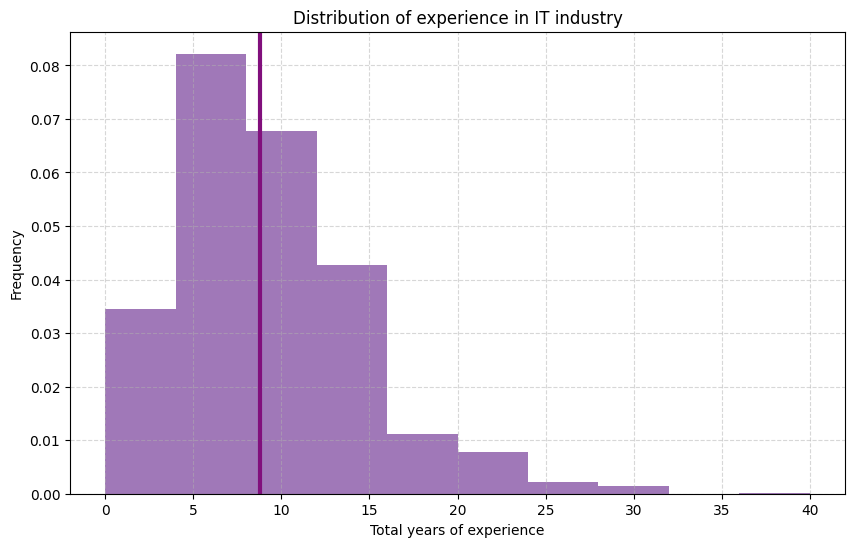

In [4]:
plt.figure(figsize=(10, 6))
n, bins, bars = plt.hist(x=df['Total years of experience'],
                         bins=10,
                         color='#8856a7',
                         alpha=0.8,
                         density=True)
plt.xlabel("Total years of experience")
plt.ylabel("Frequency")
plt.title("Distribution of experience in IT industry")

plt.axvline(x=df['Total years of experience'].mean(),
            linewidth=3,
            color='#810f7c')

plt.grid(True, linestyle='--', alpha=0.5)
plt.show()
plt.close()

- **Line Grapth**
- Line grapth for "Age" and "Total years of experience"

In [5]:
# Transfer to float
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

# Drop out the anomaly
df = df[df['Age'] < 100]

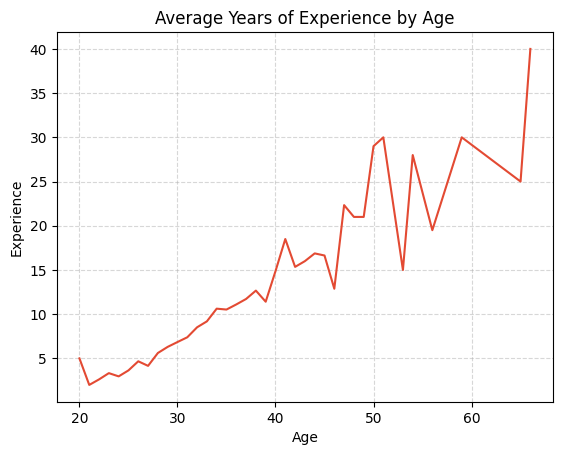

In [35]:
age_experience = df.groupby('Age')['Total years of experience'].mean()

plt.plot(age_experience.index.tolist(),
         np.array(age_experience.values),
         color='#e34a33')
plt.xlabel('Age')
plt.ylabel('Experience')
plt.title('Average Years of Experience by Age')

plt.grid(True, linestyle='--', alpha=0.5)
plt.show()
plt.close()

- **Bar Chart**
- Finding the average "Salary" for "Seniority level"

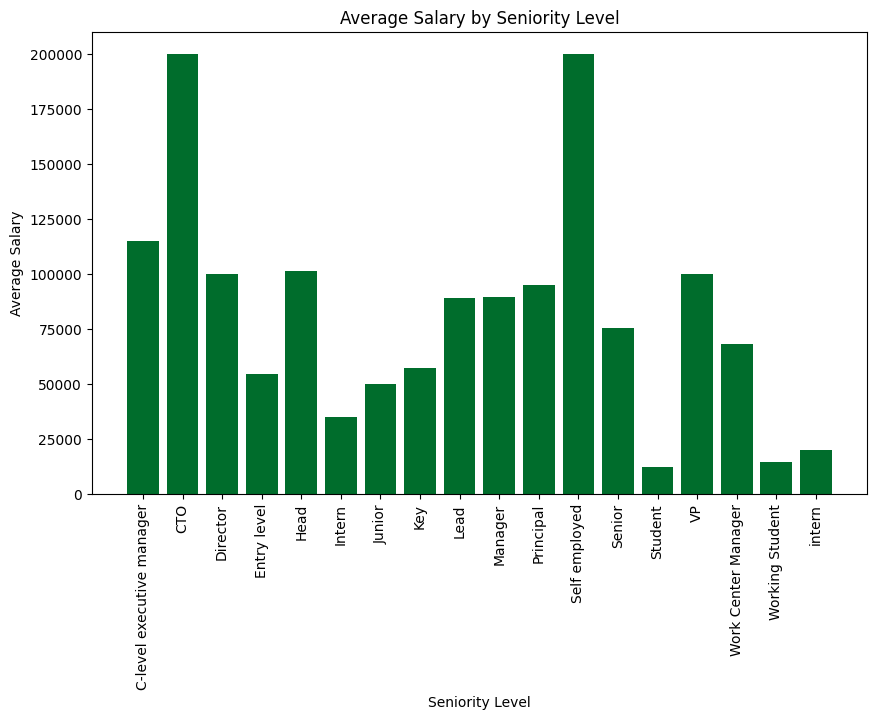

In [7]:
level_salary = df.groupby('Seniority level')['Yearly brutto salary (without bonus and stocks) in EUR'].mean().reset_index()
level_salary = level_salary.rename(columns={
    'Yearly brutto salary (without bonus and stocks) in EUR': 'Average Salary'})

# Filter out the unwanted levels
unwanted_levels = ['no idea, there are no ranges in the firm ']
level_salary = level_salary[~level_salary['Seniority level'].isin(unwanted_levels)]
unwanted_levels = ['No level', 'No level ', 'Middle']
level_salary = level_salary[~level_salary['Seniority level'].isin(unwanted_levels)]


plt.figure(figsize=(10, 6))
plt.bar(level_salary['Seniority level'],
        level_salary['Average Salary'],
        color='#006d2c')

plt.xlabel('Seniority Level')
plt.ylabel('Average Salary')
plt.title('Average Salary by Seniority Level')

plt.xticks(rotation=90)
plt.show()
plt.close()

- **Pie Chart**
- Distribution of "Company type"

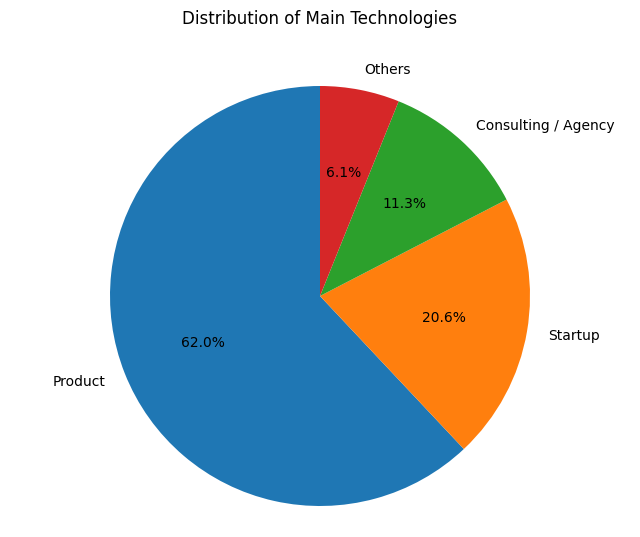

In [24]:
type_counts = df["Company type"].value_counts()
company_type_proportions = type_counts / type_counts.sum()

other_types = company_type_proportions[company_type_proportions < 0.1].index
type_counts["Others"] = type_counts[other_types].sum()

tech_counts = type_counts.drop(other_types)

plt.figure(figsize=(8, 6))
plt.pie(np.array(tech_counts.values),
        labels=tech_counts.index.tolist(),
        autopct='%1.1f%%',
        startangle=90)

plt.title('Distribution of Main Technologies', pad=30)
plt.axis('equal')

plt.show()
plt.close()

- **Box-and-Whisker Plot**
- Distribution of "Age"

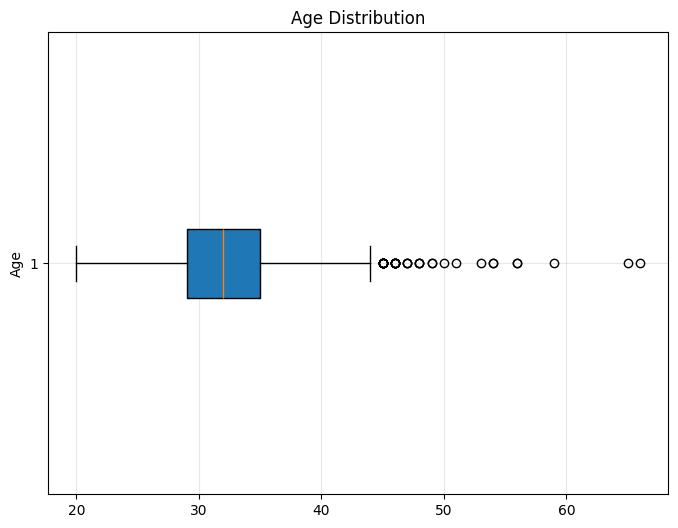

In [30]:
age = df["Age"]

plt.figure(figsize=(8, 6))
plt.boxplot(age,
            patch_artist=True,
            vert=False)

plt.ylabel('Age')
plt.title('Age Distribution')

plt.grid(True, alpha=0.3) 
plt.show()
plt.close()

- **Pair Plot**
- Relationship b/w "Experience" and "Salary" for outliner detection

In [36]:
# Drop out the anomaly
df = df[df["Yearly brutto salary (without bonus and stocks) in EUR"] < 1000000]

<Figure size 800x600 with 0 Axes>

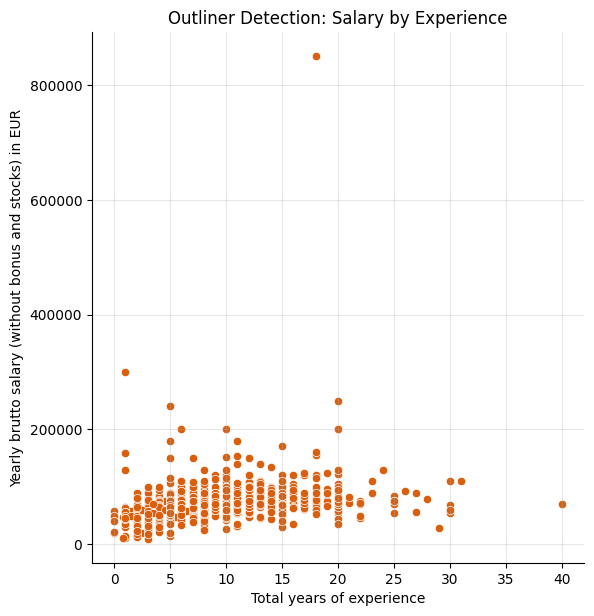

In [38]:
plt.figure(figsize=(8, 6))
sn.pairplot(data=df,
            x_vars="Total years of experience",
            y_vars="Yearly brutto salary (without bonus and stocks) in EUR",
            height=6,
            plot_kws={'color': '#d95f0e'})

plt.title('Outliner Detection: Salary by Experience')

plt.grid(True, alpha=0.3) 
plt.show()
plt.close()

- **Heatmaps**
- Correlation Matrix between "Age", "Experience", "Salary"

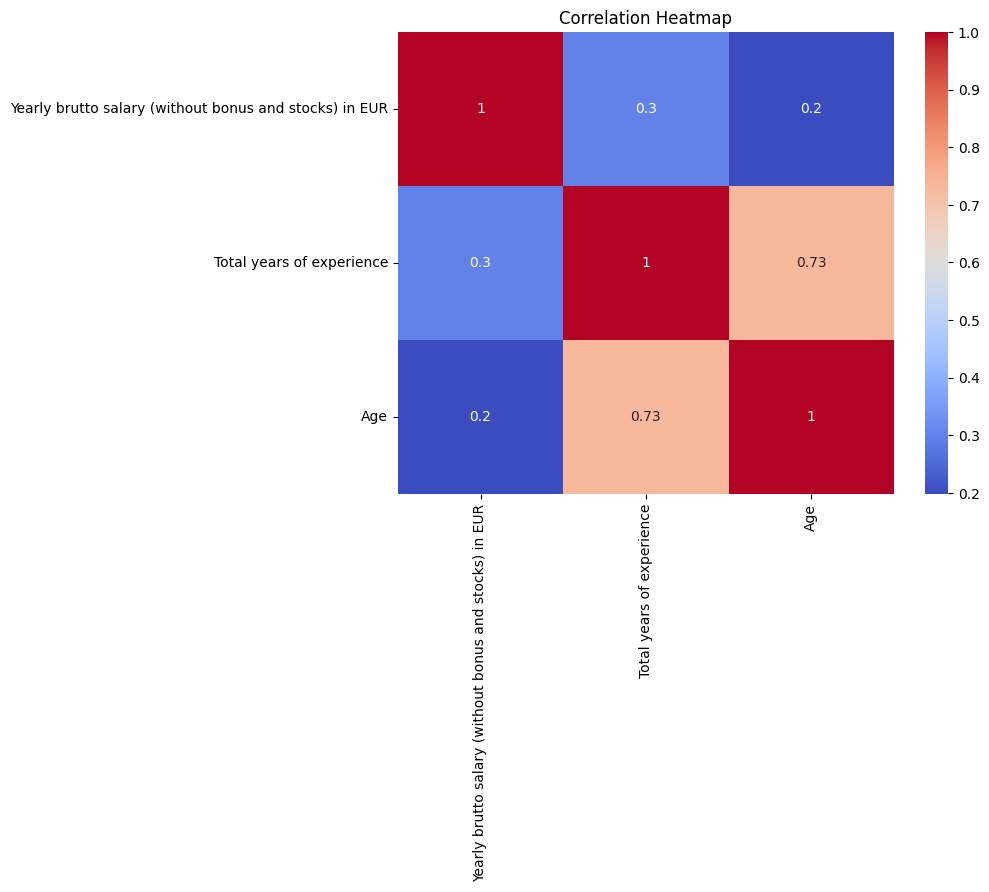

In [40]:
columns_of_interest = ["Yearly brutto salary (without bonus and stocks) in EUR",
                       "Total years of experience",
                       "Age"]
corr_matrix = df[columns_of_interest].corr()

plt.figure(figsize=(8, 6))
sn.heatmap(corr_matrix,
           annot=True,
           cmap='coolwarm')

plt.title('Correlation Heatmap')

plt.show()
plt.close()